In [ ]:
import math, sys, os
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
import contextily as ctx
from rasterio.warp import calculate_default_transform, reproject, Resampling
from shapely.geometry import Polygon
from shapely.affinity import rotate, translate
from micasense import metadata
from matplotlib import pyplot as plt
sys.path.append("d:/USDA-NIFA/Code")
os.chdir("d:/USDA-NIFA/Code")
os.getcwd()

'e:\\Desktop\\USDA-NIFA\\Code'

## Imager information

### RedEdge-MX
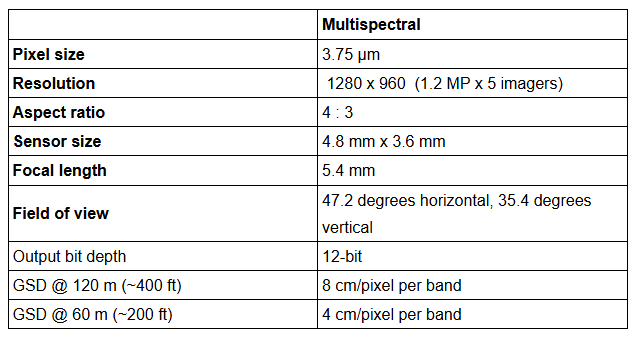
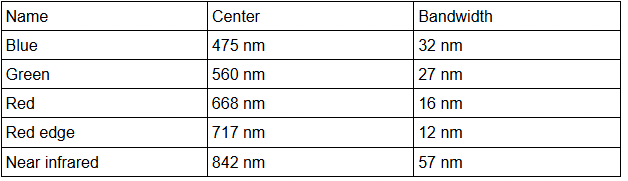

In [8]:
def calculate_fov(focal_length_mm, pixels, pixel_size_mm=0.00375):
    sensor_size_mm = pixels * pixel_size_mm
    fov_rad = 2 * math.atan(sensor_size_mm / (2 * focal_length_mm))
    return fov_rad

#### Estimate ground altitude by panel data

In [9]:
panel_pth = "B1/Panel/IMG_0000_1.tif"
meta = metadata.Metadata(panel_pth)
ground_altitude = meta.position()[2]
print(f"Ground Altitude: {ground_altitude:.2f} m")

Ground Altitude: 196.23 m


#### Mapping

In [10]:
gdf = gpd.read_file("B1/Processed/imageSet.json")
gdf = gdf.to_crs("EPSG:32616") # WGS 84 / UTM zone 16N


In [45]:
def compute_footprint(row, ground_altitude, HFOV, VFOV):
    # Calculate AGL (Height above ground)
    agl = row["altitude"] - ground_altitude
    if agl <= 0: agl = 10 # Fallback safety
    
    y, p, r = row['dls-yaw'], row['dls-pitch'], row['dls-roll']
    print(f"AGL: {agl:.2f} m, Yaw: {y:.2f} rad, Pitch: {p:.2f} rad, Roll: {r:.2f} rad")
    print(f"Yaw (deg): {math.degrees(y):.2f}, Pitch (deg): {math.degrees(p):.2f}, Roll (deg): {math.degrees(r):.2f}")

    # Dimensions in meters
    width = agl * np.tan(HFOV/2) / np.cos(p)
    height = agl * np.tan(VFOV/2) / np.cos(r)
    print(f"AGL: {agl:.2f} m, Footprint Width: {width:.2f} m, Footprint Height: {height:.2f} m")
    
    # Create base rectangle in meters centered at (0,0)
    poly = Polygon([
        (-width/2, -height/2), (width/2, -height/2),
        (width/2, height/2), (-width/2, height/2)
    ])
    
    # Rotate by yaw (converted to degrees if it's in radians)
    # Most DLS values are in radians; check if 0.39 is rad (~22 deg) or deg
    yaw_deg = math.degrees(y) 
    rotated_poly = rotate(poly, -yaw_deg, origin=(0, 0))
    
    # Move to the UTM location
    return translate(rotated_poly, xoff=row['geometry'].x, yoff=row['geometry'].y)

In [46]:
capture_path = "B1/Processed/capture"
for idx, row in gdf.iterrows():
    capture_id = row["capture_id"]
    capture_metadata = metadata.Metadata(os.path.join(capture_path, f"{capture_id}.tif"))
    capture_image_width, capture_image_height = capture_metadata.image_size()
    capture_focal_length = capture_metadata.get_item("EXIF:FocalLength")
    HFOV = calculate_fov(capture_focal_length, capture_image_width, pixel_size_mm=0.00375)
    VFOV = calculate_fov(capture_focal_length, capture_image_height, pixel_size_mm=0.00375)
    gdf.at[idx, "time"] = capture_metadata.get_item("EXIF:GPSTimeStamp")
    gdf.at[idx, "footprint"] = compute_footprint(
        row, ground_altitude, HFOV, VFOV
    )

AGL: 68.25 m, Yaw: 0.40 rad, Pitch: -0.20 rad, Roll: -0.02 rad
Yaw (deg): 22.89, Pitch (deg): -11.72, Roll (deg): -1.20
AGL: 68.25 m, Footprint Width: 30.26 m, Footprint Height: 21.85 m
AGL: 68.24 m, Yaw: 0.29 rad, Pitch: -0.22 rad, Roll: -0.02 rad
Yaw (deg): 16.54, Pitch (deg): -12.69, Roll (deg): -0.91
AGL: 68.24 m, Footprint Width: 30.37 m, Footprint Height: 21.85 m
AGL: 68.22 m, Yaw: 0.23 rad, Pitch: -0.21 rad, Roll: -0.01 rad
Yaw (deg): 13.21, Pitch (deg): -12.11, Roll (deg): -0.80
AGL: 68.22 m, Footprint Width: 30.29 m, Footprint Height: 21.84 m
AGL: 68.19 m, Yaw: 0.19 rad, Pitch: -0.20 rad, Roll: -0.01 rad
Yaw (deg): 10.86, Pitch (deg): -11.50, Roll (deg): -0.83
AGL: 68.19 m, Footprint Width: 30.21 m, Footprint Height: 21.83 m
AGL: 68.18 m, Yaw: 0.15 rad, Pitch: -0.15 rad, Roll: -0.03 rad
Yaw (deg): 8.55, Pitch (deg): -8.56, Roll (deg): -1.94
AGL: 68.18 m, Footprint Width: 29.93 m, Footprint Height: 21.84 m
AGL: 68.14 m, Yaw: 0.11 rad, Pitch: -0.18 rad, Roll: -0.05 rad
Yaw (deg)

In [47]:
gdf

,altitude,capture_id,dls-yaw,dls-pitch,dls-roll,irr-475,irr-560,irr-668,irr-842,irr-717,geometry,footprint,time
0,264.483,C66J2yEVbQEqd1DqOfxX,0.399576,-0.204540,-0.021003,1.004336,0.908405,0.809841,0.481614,0.608052,POINT (468699.494 4486223.197),"POLYGON ((468681.3059188947 4486219.016467441,...",14:26:02.315365
1,264.474,t70ahUr16cp6UH4Tin8O,0.288751,-0.221410,-0.015860,0.973489,0.884066,0.790512,0.470700,0.592624,POINT (468716.345 4486221.905),POLYGON ((468698.67987051443 4486215.756418783...,14:26:05.31556196
2,264.449,XFvoJyixESrVBi3ceTip,0.230614,-0.211274,-0.014035,0.945985,0.861420,0.771559,0.459813,0.577820,POINT (468732.349 4486220.728),"POLYGON ((468715.1101475265 4486213.558530067,...",14:26:07.307758994
3,264.424,TgLnxGi4xuMMb7gQ40vH,0.189570,-0.200687,-0.014505,0.918871,0.838744,0.752193,0.448628,0.562823,POINT (468751.063 4486219.429),POLYGON ((468734.17175058497 4486211.554396312...,14:26:09.255124056
4,264.415,TAaIqlfaTJndBYyPdBK0,0.149158,-0.149450,-0.033822,0.890362,0.814161,0.730496,0.435999,0.546281,POINT (468771.554 4486217.9),"POLYGON ((468755.1315403253 4486209.325499367,...",14:26:11.19096306
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,267.713,WrJyJUiRqKdmi1pz2gHw,-0.113793,-0.178372,-0.046018,0.836168,0.773579,0.692940,0.416478,0.517223,POINT (469301.74 4486287.298),POLYGON ((469287.37686340325 4486274.128975091...,14:36:23.25348399
296,267.702,4nnZzqNLAdMqK5XbA3rt,-0.110040,-0.188049,-0.050912,0.836056,0.773491,0.692841,0.416421,0.517143,POINT (469321.808 4486285.773),"POLYGON ((469307.370029489 4486272.653674245, ...",14:36:25.18034501
297,267.700,alltmkEK2XR53NQ97L41,-0.101572,-0.212178,-0.065845,0.836352,0.773774,0.693101,0.416589,0.517352,POINT (469341.622 4486284.36),"POLYGON ((469326.9982340281 4486271.345572355,...",14:36:27.30814991
298,267.685,uPiyAB3YxiZl2H1yjBhB,-0.102260,-0.205380,-0.055368,0.836092,0.773424,0.692733,0.416348,0.517103,POINT (469361.52 4486282.724),"POLYGON ((469346.9304645086 4486269.712132123,...",14:36:29.22142391


##### Plot the footprint

Text(0.5, 1.0, 'Camera Footprints (Red) vs Capture Points (Blue)')

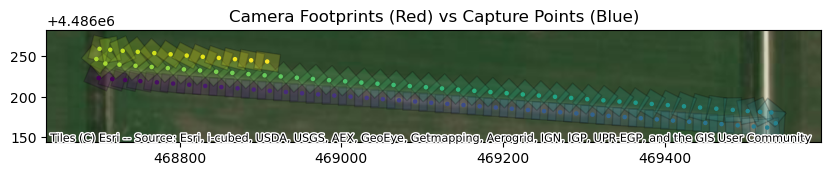

In [ ]:
# Plot according to the footprint
# Using color according to capture time
number_of_images = 100
fig, ax = plt.subplots(figsize=(10, 10))
gdf.iloc[:number_of_images].set_geometry("footprint").plot(ax=ax, alpha=0.2, edgecolor='black', column='time', cmap='viridis')
gdf.iloc[:number_of_images].set_geometry("geometry").plot(ax=ax, column='time', markersize=5, cmap='viridis')
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Esri.WorldImagery)
plt.title("Camera Footprints (Red) vs Capture Points (Blue)")

#### Download the DEM from Department of Forestry Lidar Portal
https://lidar.digitalforestry.org/